<h3>Úvod</h3>
Tento projekt vznikl v rámci kurzu Data Scientist na platformě <a href=https://www.dataquest.io/>DataQuest</a> a demonstruje využití Bayesovy věty v podobě klasifikátoru pro filtrování SMS zpráv, známého jako Naive Bayes Classifier.

<h3>Teorie</h3>

Bayesova věta popisuje vztah mezi podmíněnými pravděpodobnostmi dvou jevů, konkrétně umožňuje vyjádřit podmíněnou pravděpodobnost jednoho jevu na základě podmíněné pravděpodobnosti jevu opačného: $$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Pokud máme soubor SMS zpráv obsahující jejich text a označení, zda se jedná o spam nebo legitimní zprávu (ham), můžeme z těchto dat vypočítat pravděpodobnosti výskytu jednotlivých slov ve spamových zprávách. Tyto pravděpodobnosti pak lze použít při klasifikaci nově příchozích zpráv a určit, zda se s větší pravděpodobností jedná o spam, nebo o legitimní zprávu.

<h3>Data</h3>

Tento klasifikátor je příkladem supervizovaného strojového učení a jeho úspěšnost záleží, mimo jiné, na objemu a kvalitě dat použitých pro jeho trénování.
Použitá data obsahují pouze SMS zprávy v angličtině z roku 2011.

Zdroj dat: <br>
Almeida, T. & Hidalgo, J. (2011). SMS Spam Collection [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CC84.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

<h4>Explorační analýza</h4>

Jako první data načteme z našeho csv souboru do DataFrame objektu a prozkoumáme jejich podobu.

In [2]:
SMS_DATA_FILEPATH = r"SMSSpamCollection"
df = pd.read_csv(SMS_DATA_FILEPATH, header=None, sep="\t")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       5572 non-null   object
 1   1       5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Pracujeme s tabulkou o dvou sloupcích obsahující text 5572 SMS zpráv a označení, zdali se jedná o spam či nikoliv. Legitimní zprávy jsou označeny jako *ham*, budeme je tak nazývat dále v tomto projektu.

Jako další krok si sloupce pojmenujeme a prozkoumáme poměr spam a ham zpráv.

<Axes: ylabel='count'>

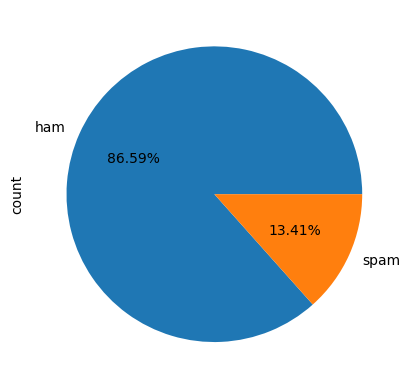

In [3]:
# přejmenování sloupců
df.columns = ["label", "sms_text"]
df["label"].value_counts().plot.pie(autopct="%.2f%%")

<h4>Rozdělení dat</h4>

Nyní bychom se mohli pustit do trénování, pokud ale všechna data využijeme na trénink, tak nebudeme mít schopnost ověřit přesnost našeho klasifikátoru. Respektive, museli bychom najít další dataset pro toto testování.

Rozdělíme si proto data na dvě části, jednu na trénink (80%) a druhou na testing (20%).

In [4]:
# před rozdělením data promícháme
df = df.sample(random_state=1, frac=1)

# na indexu níže data rozdělíme
index_split = round(df.shape[0] * 0.8)

training_df = df.iloc[0:index_split].reset_index(drop=True)
testing_df = df.iloc[index_split:].reset_index(drop=True)

print(training_df.shape, testing_df.shape)

(4458, 2) (1114, 2)


<br>
Data jsme promíchali a rozdělili na dva nové DataFrame objekty. Pro kontrolu zkontrolujeme poměr spam a ham zpráv, zdali byl zachován. 


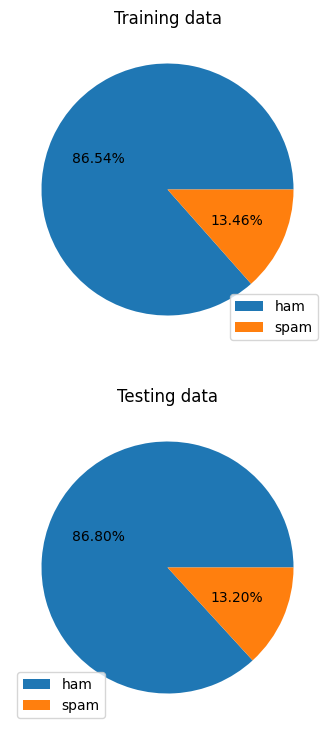

In [5]:
fig, ax = plt.subplots(nrows=2, figsize=(8, 9))


ax[0].set_title("Training data")
ax[0].pie(training_df["label"].value_counts(), autopct="%.2f%%")
ax[0].legend(training_df["label"].value_counts().index)

ax[1].set_title("Testing data")
ax[1].pie(testing_df["label"].value_counts(), autopct="%.2f%%")
ax[1].legend(testing_df["label"].value_counts().index)

Poměr byl zachován a můžeme pokračovat.

<h4>Čištění dat</h4>

Nyní se budeme věnovat především tréninkovému DataFramu.
Před tím než začneme se samotným tréninkem, potřebujeme standardizovat všechna slova do stejné podoby.
Všechny zprávy proto převedeme na malá písmena a odstraníme interpunkce a čísla.

In [6]:
training_df["sms_text"] = training_df["sms_text"].apply(
    lambda text: re.sub("\W", " ", text).lower()
)
training_df.head()

,label,sms_text
0,ham,yep by the pretty sculpture
1,ham,yes princess are you going to make me moan
2,ham,welp apparently he retired
3,ham,havent
4,ham,i forgot 2 ask ü all smth there s a card on ...


<h4>Slovník unikátních slov</h4>

Abychom mohli zjistit s jakou pravděpodobností se slova vyskytují ve spam a ham zprávách, musíme nejdříve zjistit jejich počet. Respektive musíme zjistit, kolikrát se které slovo objevilo ve spamové zprávě a kolikrát v ham zprávě.

Níže si proto vytvoříme list všech unikátních slov v našich datech, který nám poslouží jako index ke kterému budeme zaznamenávat každý výskyt daného slova.

In [7]:
vocabulary = []
for sms in training_df["sms_text"]:
    vocabulary += sms.split()

vocabulary = set(vocabulary)
vocabulary = list(vocabulary)
len(vocabulary)

7783

Máme 7783 unikátních slov.

<h4>Finální testovací data</h4>

Nyní si vytvoříme další DataFrame, kde každý řádek reprezentuje jednu SMS zprávu a každý sloupec reprezentuje unikátní slovo z našeho slovníku.
Výsledkem je DataFrame, který má 7783 sloupců a 4458 řádků.

Dále projdeme všechny naše zprávy a zaznamenáme výskyt každého slova v patřičném sloupci.

Výsledek:<br>
Suma sloupce nám řekne kolikrát se konkrétní slovo vyskytlo ve všech zprávách.<br>
Suma řádku nám řekne počet slov v konkrétní zprávě.<br>
Na intersekci sloupce a řádku pak nalezneme počet výskytů konkrétního slova v konkrétní zprávě.

In [8]:
# začneme slovníkem, kde klíč jsou jednotlivá slova z vocabulary a hodnota je list nul v délce počtu zpráv
word_counts_per_sms = {unique_word: [0] * training_df.shape[0] for unique_word in vocabulary}

# naše zprávy iterujeme zprávu po zprávě a slovo po slovu
for index, sms in enumerate(training_df["sms_text"].str.split()):
    for word in sms:
        # u každého slova inkrementujeme o 1 na patřičném indexu
        word_counts_per_sms[word][index] += 1

# finální slovník převedeme na DataFrame
word_counts_per_sms = pd.DataFrame(word_counts_per_sms, index=training_df.index)

In [9]:
word_counts_per_sms.head()

,thia,adding,usps,se,favour,maruti,needle,nursery,31p,possibility,...,rcb,erupt,dessert,theoretically,smoothly,necessarily,ashley,lei,valuing,cruise
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Tento nový DataFrame napojíme na náš již existující trénovací DataFrame.

In [10]:
training_df = training_df.join(word_counts_per_sms)
training_df.head()

,label,sms_text,thia,adding,usps,se,favour,maruti,needle,nursery,...,rcb,erupt,dessert,theoretically,smoothly,necessarily,ashley,lei,valuing,cruise
0,ham,yep by the pretty sculpture,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ham,yes princess are you going to make me moan,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ham,welp apparently he retired,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ham,havent,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ham,i forgot 2 ask ü all smth there s a card on ...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Než pokročíme dále, provedeme jednoduchou namátkovou kontrolu. 
V datech vidíme, že první tři zprávy mají 5, 9 a 4 slova. Tomu by měl odpovídat také součet všech čísel v řádku.

In [11]:
print(
    word_counts_per_sms.iloc[0].sum(),
    word_counts_per_sms.iloc[1].sum(),
    word_counts_per_sms.iloc[2].sum()
)

5 9 4


Všechno je v pořádku, takže pokračujeme.

<h4>Více teorie</h4>
Data máme připravena a můžeme začít počítat.

Představme si, že máme zprávu o dvou slovech: **"Good Day"**.

Pokud vezmeme počet spamových zpráv obsahující slovo `"Good"`, a vydělíme ho celkovým počtem všech spamových zpráv, zjistíme, s jakou pravděpodobností Spam obsahuje slovo `"Good"`:
$$P(\text{Good} \mid \text{Spam})$$

Stejný postup aplikujeme i na slovo `"Day"`. Naive Bayes vychází z předpokladu podmíněné nezávislosti slov, tedy že výskyt jednoho slova nezávisí na výskytu ostatních slov ve zprávě. Díky tomu můžeme jednotlivé pravděpodobnosti mezi sebou násobit. Získáme tak pravděpodobnost, že spamová zpráva obsahuje slova `"Good"` a `"Day"`.

$$P(\text{Good} \cap \text{Day} \mid \text{Spam}) = P(\text{Good} \mid \text{Spam}) \cdot P(\text{Day} \mid \text{Spam})$$

Nyní náš výsledek vynásobíme celkovou pravděpodobností, že náhodná zpráva v našem datasetu je spam: $P(\text{Spam})$ (tuto pravděpodobnost zjistíme vydělením počtu spamových zpráv počtem všech zpráv). Tím získáme pravděpodobnost, že zpráva obsahuje slova `"Good"` a `"Day"` a že je spam:

$$P(\text{Good} \cap \text{Day} \cap \text{Spam}) = P(\text{Spam}) \cdot P(\text{Good} \cap \text{Day} \mid \text{Spam})$$

Abychom mohli aplikovat Bayesovu větu, potřebujeme ještě zjistit s jakou pravděpodobností jsou ve zprávách slova `"Good"` a `"Day"` (ať už se jedná o spam, nebo ham). Pro tyto účely musíme také zjistit, jaká je pravděpodobnost výskytu `"Good"` a `"Day"` v případě ham zpráv. Poté můžeme aplikovat zákon o úplné pravděpodobnosti:

$$P(\text{Good} \cap \text{Day}) = P(\text{Good} \cap \text{Day} \mid \text{Spam}) \cdot P(\text{Spam}) + P(\text{Good} \cap \text{Day} \mid \text{Ham}) \cdot P(\text{Ham})$$

Nyní máme vše připravené pro finální výpočet Bayesovy věty:

$$P(\text{Spam} \mid \text{Good} \cap \text{Day}) = \frac{P(\text{Good} \cap \text{Day} \cap \text{Spam})}{P(\text{Good} \cap \text{Day})}$$

Tímto jsme právě zjistili následující -> Když nám přijde zpráva obsahující pouze slova **"Good"** a **"Day"**, tak s jakou pravděpodobností se jedná o Spam.

<h4>Úpravy pro účely výpočtu</h4>

V našem případě přesnou pravděpodobnost počítat nepotřebujeme. Stačí jen zjistit, jestli se spíše jedná o spam, nebo o ham.
Jako první úpravu můžeme vynechat závěrečné dělení Bayesovy věty. Její výsledek je totiž přímo úměrný čitateli:

$$P(\text{Spam} \mid w_1, w_2, \dots, w_n) \propto P(w_1, w_2, \dots, w_n \mid \text{Spam}) \cdot P(\text{Spam})$$

Stejně postupujeme u $P(\text{Ham} \mid w_1, w_2, \dots, w_n)$. Porovnáním výsledků pak zjistíme, jestli je zpráva spíše spam nebo ham.<br>

Jako další změnu nebudeme porovnávat počet výskytů slova ve spamu a hamu oproti počtu spam/ham zpráv. Ale četnost konkrétního slova v jedné třídě (spam/ham) vydělíme počtem všech slov ze stejné třídy. Tím náš klasifikátor zohlední opakování se slova v jedné zprávě.

V praxi samozřejmě budeme pracovat s více než pouze dvěma slovy jako v našem příkladě **"Good Day"**, univerzální zápis proto vypadá následovně:

$$P(\text{Spam} \mid w_1, w_2, \dots, w_n) \propto P(\text{Spam}) \cdot \prod_{i=1}^{n} P(w_i \mid \text{Spam})$$
$$P(\text{Ham} \mid w_1, w_2, \dots, w_n) \propto P(\text{Ham}) \cdot \prod_{i=1}^{n} P(w_i \mid \text{Ham})$$

Takže pro každé slovo ve zprávě budeme počítat, zdali na toto slovo narazíme spíš ve spamu, nebo v hamu. Zde se nám může stát, že nějaké slovo existuje pouze v jedné kategorii. V takovém případě bychom násobili nulou a to by zkazilo náš výsledek. Musíme proto o pár kroků zpět a znovu definovat: $$P(w \mid \text{Spam}) = \frac{N_{w,\text{Spam}}}{N_\text{Spam}}$$

Zde použijeme tzv. *additive smoothing*. Určíme si vyhlazovací parametr $\alpha = 1$ který přidáme do čitatele. Jmenovateli pak přidáme počet všech unikátních slov vynásobeným $\alpha$, tedy 1. Touto metodou zamezíme násobení nulou: 

$$P(w \mid \text{Spam}) = \frac{N_{w,\text{Spam}} + \alpha}{N_{\text{Spam}} + \alpha \cdot N_\text{Vocabulary}}$$

Nyní nám zbývá tuto teorii už jen aplikovat. 

<h4>Aplikace</h4>

Některé hodnoty, jako $P(\text{Spam})$, nebo $N_Vocabulary$ se nemění. Tyto konstanty proto určíme jako první.

In [12]:
spam_df = training_df.loc[training_df["label"]=="spam"]
ham_df = training_df.loc[training_df["label"]=="ham"]

alpha = 1

# počet slov ve spamových zprávách
N_spam = spam_df.sum()
N_spam = N_spam[2:].sum()

# počet slov v ham zprávách
N_ham = ham_df.sum()
N_ham = N_ham[2:].sum()

# počet unikátních slov
N_vocabulary = training_df.shape[1] - 2

P_spam = training_df["label"].value_counts(normalize=True)["spam"]
P_ham = training_df["label"].value_counts(normalize=True)["ham"]

print(f"{N_spam=}\n{N_ham=}\n{N_vocabulary=}\n{P_spam=}\n{P_ham=}")

N_spam=15190
N_ham=57237
N_vocabulary=7783
P_spam=0.13458950201884254
P_ham=0.8654104979811574


Dále si určíme $P(w \mid \text{Spam})$ a $P(w \mid \text{Ham})$ pro všechna unikátní slova.
Tato data dáme do slovníků kde klíčem je slovo a hodnotou pravděpodobnost vypočítaná podle vzorce výše.

In [13]:
P_words_given_spam = {}
P_words_given_ham = {}

for word in vocabulary:
    P_words_given_spam[word] = (spam_df[word].sum() + alpha) / (N_spam + (N_vocabulary * alpha))
    P_words_given_ham[word] = (ham_df[word].sum() + alpha) / (N_ham + (N_vocabulary * alpha))

A jako poslední vytvoříme funkci, která přijme novou zprávu, rozdělí ji na jednotlivá slova a tato slova najde v našich právě definovaných slovnících.
Na základě součinu nalezených pravděpodobností s $P(\text{Spam})$ a $P(\text{Ham})$ pak určí, zda se s větší pravděpodobností jedná o Spam nebo Ham.
Slova, která se nevyskytují v našich testovacích datech jsou ignorována.

In [14]:
def classify_message(message: str) -> str:
    message = re.sub("\W", " ", message).lower().split()

    P_spam_given_message = 1
    P_ham_given_message = 1

    for word in message:
        if word in P_words_given_spam:
            P_spam_given_message *= P_words_given_spam[word]
            
        if word in P_words_given_ham:
            P_ham_given_message *= P_words_given_ham[word]

    P_spam_given_message *= P_spam
    P_ham_given_message *= P_ham

    result = "spam" if P_spam_given_message > P_ham_given_message else "ham"
    return result

A to je všechno. Pojdmě zjistit, zdali naše funkce funguje.
Na začátku jsme si vyhradili část dat pro testování:

In [15]:
testing_df.head()

,label,sms_text
0,ham,Later i guess. I needa do mcat study too.
1,ham,But i haf enuff space got like 4 mb...
2,spam,Had your mobile 10 mths? Update to latest Oran...
3,ham,All sounds good. Fingers . Makes it difficult ...
4,ham,"All done, all handed in. Don't know if mega sh..."


Tato data jsou správně označená. Můžeme proto vytvořit nový sloupec, ve kterém se naše funkce pokusí určit správné označení a tento sloupec pak porovnat s označením původním.

In [16]:
testing_df["predict"] = testing_df["sms_text"].apply(lambda text: classify_message(text))

In [17]:
print(testing_df.shape)
testing_df.head()

(1114, 3)


,label,sms_text,predict
0,ham,Later i guess. I needa do mcat study too.,ham
1,ham,But i haf enuff space got like 4 mb...,ham
2,spam,Had your mobile 10 mths? Update to latest Oran...,spam
3,ham,All sounds good. Fingers . Makes it difficult ...,ham
4,ham,"All done, all handed in. Don't know if mega sh...",ham


In [18]:
correct = (testing_df["label"] == testing_df["predict"]).sum()
success_rate = round((correct / testing_df.shape[0]) * 100, 2)
print(f"{success_rate}%")

98.83%


Tato testovací data mají 1114 zpráv a náš klasifikátor z nich určil 98.83% správně. Můžeme se pro zvědavost podívat, kde přesně se náš klasifikátor "seknul".

In [19]:
pd.crosstab(
    testing_df["label"],
    testing_df["predict"],
    margins=True
)

predict,ham,spam,All
label,,,
ham,962,5,967
spam,8,139,147
All,970,144,1114


Tady vidíme, že klasifikátor mylně zařadil 13 zpráv. 8 spamových označil za ham a 5 ham označil za spam.

<h4>Limity</h4>
Náš klasifikátor funguje nejlépe na krátkých zprávách v angličtině, bez smajlíků a v komunikačním stylu typickém pro rok 2011.

Klasifikátor je dále limitován předpokladem, že jsou na sobě jednotlivá slova nezávislá, což v reálném světě neplatí.

Dále by naše implementace mohla být vylepšena i po technické stránce. Například mezi sebou násobíme pravděpodobnosti jednotlivých slov v původní podobě. Pro klasifikaci krátkých zpráv to nevadí, ale v případě delších textů bychom tímto násobením mohli vytvořit číslo se spoustou desetinných míst, které by nám Python zaokrouhlil na nulu.

Pro účely tohoto projektu jsou však dosažené výsledky dostatečné.